In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## read the data
data = pd.read_csv(r'C:\Users\sbadiger\AI_Practice_Excelr\datasets\advertising.csv')

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [7]:
num_data =  data._get_numeric_data()
num_data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


In [8]:
num_data.rename(columns={
    'Clicked on Ad':'Clicked'},
                inplace=True)

In [9]:
num_data.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male', 'Clicked'],
      dtype='object')

In [13]:
#### Split the data into train and test
from sklearn.model_selection import train_test_split
X = num_data.drop('Clicked', axis=1)
y = num_data['Clicked']

In [11]:
X.head(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male
0,68.95,35,61833.90,256.09,0
1,80.23,31,68441.85,193.77,1
2,69.47,26,59785.94,236.50,0


In [12]:
y.head(3)

0    0
1    0
2    0
Name: Clicked, dtype: int64

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) ### random state will help you keep same data everytime we run this code. same random set of value we ll get
X_train.shape,X_test.shape,y_train.shape,y_test.shape
                                                

((800, 5), (200, 5), (800,), (200,))

In [19]:
X_train.head()  ###it splits randomly

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male
985,72.88,44,64011.26,125.12,0
337,75.32,28,59998.50,233.60,1
66,63.89,40,51317.33,105.22,0
825,83.69,36,68717.00,192.57,0
607,65.22,30,66263.37,240.09,1


In [20]:
###Build the Model
#till certain point logistic regression is linear regression itself
from sklearn.linear_model import LogisticRegression


In [21]:
model = LogisticRegression(max_iter=400)

In [23]:
## Train the model
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
### Evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

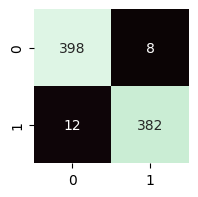

In [50]:
### Training data
yhat_train = model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
cm
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False,cmap='mako')
plt.show()

In [37]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       406
           1       0.98      0.97      0.97       394

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.97       800
weighted avg       0.98      0.97      0.97       800



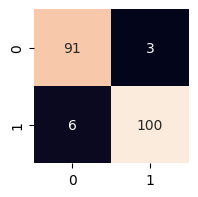

In [49]:
yhat_test = model.predict(X_test)
cm_test = confusion_matrix(y_test,yhat_test)
cm_test
plt.figure(figsize=(2,2))
sns.heatmap(cm_test,annot=True,fmt='d',cbar=False)
plt.show()

In [39]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        94
           1       0.97      0.94      0.96       106

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.95      0.96       200



In [31]:
### This is a very good model and it is correcfit, bcz both for training and testing it gave same and high percentage of accuracy.

In [45]:
def plot_roc(y,yhat):
   fpr,tpr,thresh = roc_curve(y,yhat)
   auc = roc_auc_score(y,yhat)
   print(f'AUC : {auc}')
   plt.figure(figsize=(3,3))

   plt.title('AUC - ROC curve ',fontsize=15)
   plt.xlabel('False Positive Rate(FPR)')
   plt.ylabel('True Positive Rate(TPR)')

   plt.plot(fpr,tpr)
   plt.plot([0,1],[0,1],'o--')
   plt.show()
   

AUC : 0.9749193568552925


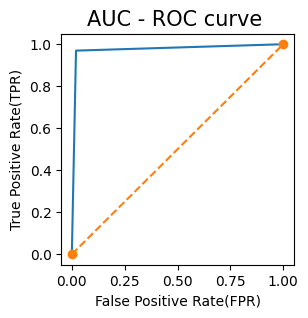

In [46]:
plot_roc(y_train,yhat_train)

AUC : 0.9557406663990365


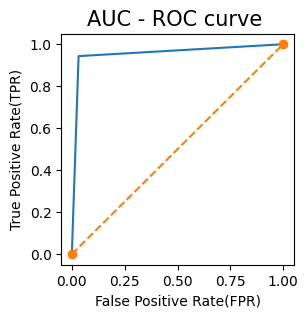

In [47]:
plot_roc(y_test,yhat_test)